<a href="https://colab.research.google.com/github/Resh-ma050706/Deep-learning/blob/main/24BAD097_DL_EXP_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# ============================================================
# TASK A: DATASET PREPARATION - TINY SHAKESPEARE
# S.RESHMA 24BAD097
# ============================================================

# Install required library
!pip install -q tensorflow

# Import libraries
import numpy as np
import urllib.request

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
print("S.RESHMA 24BAD097")
print("Libraries imported successfully!")

# ------------------------------------------------------------
# 1. DOWNLOAD TINY SHAKESPEARE DATASET
# ------------------------------------------------------------

url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"

urllib.request.urlretrieve(
    url,
    "tiny_shakespeare.txt"
)

print("\nTiny Shakespeare dataset downloaded successfully!")

# ------------------------------------------------------------
# 2. LOAD DATASET
# ------------------------------------------------------------

with open("tiny_shakespeare.txt", "r", encoding="utf-8") as file:
    text = file.read()

print("\nDataset loaded successfully!")
print("Total characters:", len(text))

# ------------------------------------------------------------
# 3. EXPLORE DATASET
# ------------------------------------------------------------

print("\nFirst 500 characters:")
print(text[:500])

# ------------------------------------------------------------
# 4. CONVERT TEXT TO LOWERCASE
# ------------------------------------------------------------

text = text.lower()

print("\nText converted to lowercase.")

# ------------------------------------------------------------
# 5. TOKENIZE TEXT INTO WORDS
# ------------------------------------------------------------

tokenizer = Tokenizer(
    oov_token="<OOV>",
    filters='!"#$%&()*+,-./:;=?@[\\]^_`{|}~\t\n'
)

tokenizer.fit_on_texts([text])

# Convert words into integer indexes
tokens = tokenizer.texts_to_sequences([text])[0]

# Vocabulary size
total_words = len(tokenizer.word_index) + 1

print("\nVocabulary size:", total_words)

print("\nFirst 20 words and their indexes:")
print(list(tokenizer.word_index.items())[:20])

# ------------------------------------------------------------
# 6. GENERATE INPUT SEQUENCES
# ------------------------------------------------------------

sequence_length = 10

input_sequences = []

for i in range(sequence_length, len(tokens)):
    sequence = tokens[i-sequence_length:i+1]
    input_sequences.append(sequence)

input_sequences = np.array(input_sequences)

print("\nTotal sequences:", len(input_sequences))

print("\nExample sequence:")
print(input_sequences[0])

# ------------------------------------------------------------
# 7. SEPARATE INPUT AND TARGET
# ------------------------------------------------------------

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("\nX shape:", X.shape)
print("y shape:", y.shape)

# ------------------------------------------------------------
# 8. APPLY SEQUENCE PADDING
# ------------------------------------------------------------

X = pad_sequences(
    X,
    maxlen=sequence_length,
    padding="pre"
)

print("\nAfter padding:")
print("X shape:", X.shape)

# ------------------------------------------------------------
# 9. TRAINING AND VALIDATION SPLIT
# ------------------------------------------------------------

split_index = int(0.8 * len(X))

X_train = X[:split_index]
y_train = y[:split_index]

X_val = X[split_index:]
y_val = y[split_index:]

print("\nTRAINING DATA")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nVALIDATION DATA")
print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

# ------------------------------------------------------------
# 10. DISPLAY SAMPLE INPUT AND TARGET WORD
# ------------------------------------------------------------

index_word = {
    index: word
    for word, index in tokenizer.word_index.items()
}

sample_input = [
    index_word.get(i, "<UNK>")
    for i in X_train[0]
]

target_word = index_word.get(
    y_train[0],
    "<UNK>"
)

print("\nSample input words:")
print(sample_input)

print("\nTarget next word:")
print(target_word)

S.RESHMA 24BAD097
Libraries imported successfully!

Tiny Shakespeare dataset downloaded successfully!

Dataset loaded successfully!
Total characters: 1115394

First 500 characters:
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor

Text converted to lowercase.

Vocabulary size: 12634

First 20 words and their indexes:
[('<OOV>', 1), ('the', 2), ('and', 3), ('to', 4), ('i', 5), ('of', 6), ('you', 7), ('my', 8), ('a', 9), ('that', 10), ('in', 11), ('is', 12), ('not', 13), ('for', 14), ('with', 15), ('me', 16), ('it', 17), ('be', 18), ('your', 19

In [4]:
# ============================================================
# TASK B: IMPLEMENTING THE RNN MODEL
# S.RESHMA 24BAD097
# ============================================================

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

# ------------------------------------------------------------
# 1. CREATE RNN MODEL
# ------------------------------------------------------------

embedding_dim = 64
rnn_units = 128

model = Sequential([

    # Embedding layer
    Embedding(
        input_dim=total_words,
        output_dim=embedding_dim
    ),

    # Simple RNN layer
    SimpleRNN(
        rnn_units
    ),

    # Dense output layer with Softmax
    Dense(
        total_words,
        activation="softmax"
    )
])

# ------------------------------------------------------------
# 2. COMPILE THE MODEL
# ------------------------------------------------------------

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
print("S.RESHMA 24BAD097")

print("RNN model created and compiled successfully!")

# ------------------------------------------------------------
# 3. DISPLAY MODEL ARCHITECTURE
# ------------------------------------------------------------

print("\nMODEL SUMMARY")
print("=" * 60)

model.summary()

# ------------------------------------------------------------
# 4. DISPLAY LAYER INFORMATION
# ------------------------------------------------------------

print("\nMODEL ARCHITECTURE")
print("=" * 60)

for layer in model.layers:
    print(layer.name, "->", layer.output_shape if hasattr(layer, "output_shape") else "Output shape available after build")


S.RESHMA 24BAD097
RNN model created and compiled successfully!

MODEL SUMMARY


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


MODEL ARCHITECTURE
embedding -> Output shape available after build
simple_rnn -> Output shape available after build
dense -> Output shape available after build


In [6]:
# ============================================================
# TASK C: FASTER TRAINING SETUP
# S.RESHMA 24BAD097
# ============================================================

# Use a smaller portion of the training and validation data
# for faster execution

train_size = 50000
val_size = 10000

X_train_small = X_train[:train_size]
y_train_small = y_train[:train_size]

X_val_small = X_val[:val_size]
y_val_small = y_val[:val_size]

print("Training samples:", len(X_train_small))
print("Validation samples:", len(X_val_small))

Training samples: 50000
Validation samples: 10000


S.RESHMA 24BAD097
Training samples: 20000
Validation samples: 5000
Epoch 1/3
40/40 ━━━━━━━━━━━━━━━━━━━━ 14s 344ms/step - accuracy: 0.2201 - loss: 4.0419 - val_accuracy: 0.0828 - val_loss: 6.6915
Epoch 2/3
40/40 ━━━━━━━━━━━━━━━━━━━━ 14s 359ms/step - accuracy: 0.2351 - loss: 3.9342 - val_accuracy: 0.0832 - val_loss: 6.7180
Epoch 3/3
40/40 ━━━━━━━━━━━━━━━━━━━━ 14s 358ms/step - accuracy: 0.2511 - loss: 3.8345 - val_accuracy: 0.0830 - val_loss: 6.7621
S.RESHMA 24BAD097

FINAL PERFORMANCE
Training Accuracy   : 0.2511
Validation Accuracy : 0.083
Training Loss       : 3.8345
Validation Loss     : 6.7621


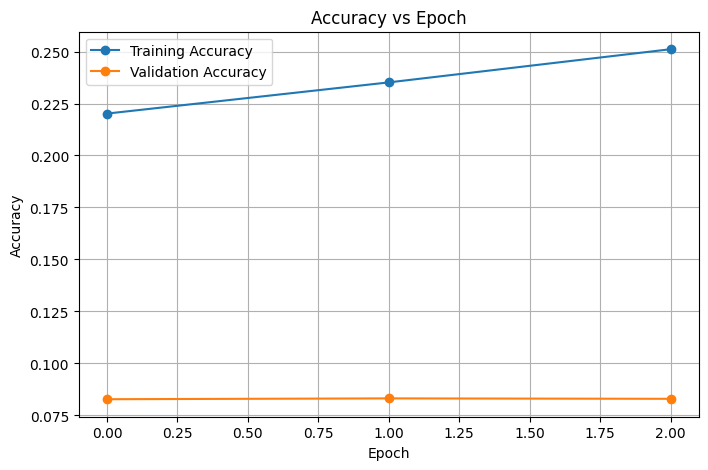

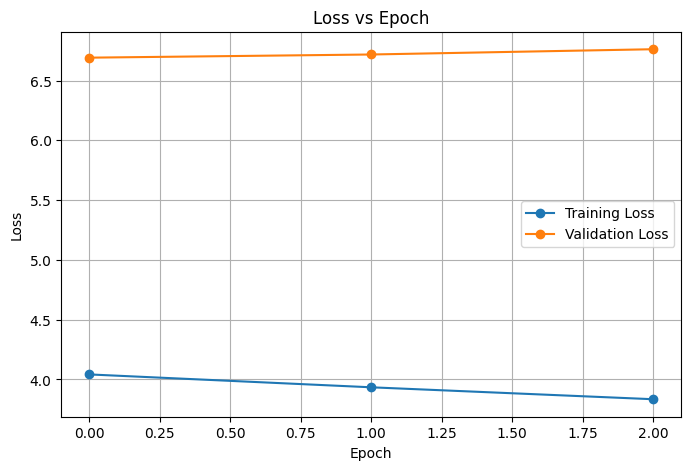


VALIDATION EVALUATION
Validation Loss     : 6.7621
Validation Accuracy : 0.083


In [10]:
# ============================================================
# TASK C: RNN TRAINING AND PERFORMANCE EVALUATION
# FAST VERSION
# S.RESHMA 24BAD097
# ============================================================

import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. USE SMALLER DATASET FOR FASTER TRAINING
# ------------------------------------------------------------

train_size = 20000
val_size = 5000

X_train_small = X_train[:train_size]
y_train_small = y_train[:train_size]

X_val_small = X_val[:val_size]
y_val_small = y_val[:val_size]
print("S.RESHMA 24BAD097")
print("Training samples:", len(X_train_small))
print("Validation samples:", len(X_val_small))

# ------------------------------------------------------------
# 2. TRAIN THE MODEL
# ------------------------------------------------------------

history = model.fit(
    X_train_small,
    y_train_small,
    epochs=3,
    batch_size=512,
    validation_data=(X_val_small, y_val_small),
    verbose=1
)

# ------------------------------------------------------------
# 3. RECORD PERFORMANCE
# ------------------------------------------------------------

train_accuracy = history.history["accuracy"][-1]
val_accuracy = history.history["val_accuracy"][-1]

train_loss = history.history["loss"][-1]
val_loss = history.history["val_loss"][-1]
print("S.RESHMA 24BAD097")
print("\n========================================")
print("FINAL PERFORMANCE")
print("========================================")

print("Training Accuracy   :", round(train_accuracy, 4))
print("Validation Accuracy :", round(val_accuracy, 4))
print("Training Loss       :", round(train_loss, 4))
print("Validation Loss     :", round(val_loss, 4))

# ------------------------------------------------------------
# 4. ACCURACY VS EPOCH
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.title("Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

# ------------------------------------------------------------
# 5. LOSS VS EPOCH
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.title("Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

# ------------------------------------------------------------
# 6. VALIDATION EVALUATION
# ------------------------------------------------------------

val_loss_result, val_accuracy_result = model.evaluate(
    X_val_small,
    y_val_small,
    verbose=0
)

print("\n========================================")
print("VALIDATION EVALUATION")
print("========================================")

print("Validation Loss     :", round(val_loss_result, 4))
print("Validation Accuracy :", round(val_accuracy_result, 4))


In [11]:
# ============================================================
# TASK D: DEEP LEARNING EXPERIMENT MANAGEMENT
# S.RESHMA 24BAD097
# ============================================================

import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences

# ------------------------------------------------------------
# 1. CREATE INDEX-TO-WORD MAPPING
# ------------------------------------------------------------

index_word = {
    index: word
    for word, index in tokenizer.word_index.items()
}

# ------------------------------------------------------------
# 2. FUNCTION TO GENERATE TEXT
# ------------------------------------------------------------

def generate_text(seed_text, next_words=20):

    result = seed_text.lower()

    for _ in range(next_words):

        # Convert seed text into numbers
        token_list = tokenizer.texts_to_sequences([result])[0]

        # Keep only the last 10 words
        token_list = token_list[-sequence_length:]

        # Apply padding
        token_list = pad_sequences(
            [token_list],
            maxlen=sequence_length,
            padding="pre"
        )

        # Predict next word
        predictions = model.predict(
            token_list,
            verbose=0
        )

        predicted_index = np.argmax(predictions[0])

        # Convert predicted number back to word
        predicted_word = index_word.get(
            predicted_index,
            ""
        )

        # Stop if no word is predicted
        if predicted_word == "":
            break

        # Add predicted word to the sentence
        result = result + " " + predicted_word

    return result


# ------------------------------------------------------------
# 3. GENERATE TEXT USING DIFFERENT SEED INPUTS
# ------------------------------------------------------------

seed_inputs = [
    "to be or not to",
    "the king is",
    "my lord",
    "good night",
    "what is"
]
print("S.RESHMA 24BAD097")
print("============================================================")
print("GENERATED TEXT SAMPLES")
print("============================================================")

for seed in seed_inputs:

    generated_text = generate_text(
        seed,
        next_words=20
    )

    print("\nSeed Input:")
    print(seed)

    print("\nGenerated Text:")
    print(generated_text)

    print("\n" + "-" * 60)


# ------------------------------------------------------------
# 4. OBSERVATION
# ------------------------------------------------------------

print("\n============================================================")
print("OBSERVATION")
print("============================================================")

print("""
1. The RNN generates text by predicting one word at a time.

2. The prediction of each new word depends on the previous
   sequence of words.

3. Different seed inputs produce different generated text.

4. The generated text follows patterns learned from the
   Tiny Shakespeare dataset.

5. Some generated sentences are contextually meaningful,
   while others may contain repetition or grammatical errors.

6. This shows that the RNN has learned sequential patterns
   from the training data.
""")

S.RESHMA 24BAD097
GENERATED TEXT SAMPLES

Seed Input:
to be or not to

Generated Text:
to be or not to be entombed in the people and the people are in the people and the common toe of the people and

------------------------------------------------------------

Seed Input:
the king is

Generated Text:
the king is ope and make a quarry to extol him and i am content to rome and the people coriolanus i pray

------------------------------------------------------------

Seed Input:
my lord

Generated Text:
my lord of humility i have a man to be a man to be a man to be a man to be

------------------------------------------------------------

Seed Input:
good night

Generated Text:
good night ' ' thou hast a single death and when it were a man that would be not in the people

------------------------------------------------------------

Seed Input:
what is

Generated Text:
what is thy name thou hast thou hast not be ruled to be a man that that the belly is not to

--------------------------